## Описание проекта
Цель нашего исследования на основе данных интернет-магазина «Стримчик» понять, на что потратить рекламный бюджет. В исследовании мы проанализировали игры с помощью разных метрик (платформы, жанры, возрастные рейтинги, регионы, отзывы), чтобы выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

## В ходе исследования мы:

1. Ознакомимся с данными
2. Обработаем датасет
3. Проведем исследовательский анализ данных
4. Выявим потребительские особености для каждого региона
5. Проверим некоторые гипотезы
6. Датасет охватывает период с 1980 года по 2016 год.

# Шаг 1. Загрузка данных

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [2]:
# Загрузим данные из CSV-файла в DataFrame 'users' и выводим первые несколько строк
games = pd.read_csv('/datasets/games.csv', sep =",")
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
# Вывод информации о датафрейме 
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Заменим названия столбцов и приведим к нижнему регистру. Также видим, что нужно будет преобразовать тип данных в некоторых столбцах - н-р, Year_of_Release и User_Score.

In [4]:
#Приводим к нижнему регистру
games.columns = games.columns.str.lower()

# Проверка
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Получим количества строк в датафрейм 'games' для того, чтобы проверить
#  % оставшихся данных после предобработки данных
rz = games.shape[0]

# Шаг 2. Предобработка данных

Преобразуем данные в нужные типы. Изменим тип данных в столбце 'user_score' и передем его из 'object' в числовой ('float64').
Нам заранее известно, что в столбце есть значения **'tbd' (to be determined)** в столбце 'user_score', это значение используется в игровой индустрии для обозначения того, что оценка пользователей еще не определена и будет уточнена в будущем. Оно может появиться, например, когда игра только вышла, и пользовательских оценок пока нет. 

Добавим опцию errors='coerce', которая при обнаружении невалидных (не числовых) значений, в нашем случае 'tbd', заменит на NaN (Not a Number).

In [6]:
# Изменение типа данных в столбце 'user_score' и замена tbd на Nan
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')


Изменим тип данных в столбце с датой выпуска игры

In [7]:
games['year_of_release'] = games['year_of_release'].astype('Int64')

Проверим пропуски в датафрейме.

In [8]:
# Проверка на пропуски в данных 
games.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Есть значительные пропуски в critic_score, user_score, rating - возможно какие-то игры не были оценены критиками или пользователями, из-за чего данные отсутствуют. 

In [9]:
# Проверка на дубликаты
games.duplicated().sum()

0

Дубликатов нет, на первый взгляд. однако попробуем поискать дубликаты сразу по нескольким основным столбцам. 

In [10]:
duplicate_rows = games.duplicated(subset=['name', 'year_of_release', 'platform'], keep=False)
duplicates = games[duplicate_rows]

# Выводим найденные дубликаты
print(duplicates)


                name platform  year_of_release   genre  na_sales  eu_sales  \
604    Madden NFL 13      PS3             2012  Sports      2.11      0.22   
659              NaN      GEN             1993     NaN      1.78      0.53   
14244            NaN      GEN             1993     NaN      0.00      0.00   
16230  Madden NFL 13      PS3             2012  Sports      0.00      0.01   

       jp_sales  other_sales  critic_score  user_score rating  
604        0.00         0.23          83.0         5.5      E  
659        0.00         0.08           NaN         NaN    NaN  
14244      0.03         0.00           NaN         NaN    NaN  
16230      0.00         0.00          83.0         5.5      E  


In [11]:
games.drop_duplicates(subset=['name', 'year_of_release', 'platform'], keep='first', inplace=True)

Можем удалить данные дубликаты, оставив первые строки, так как в них мы видим более полную информацию.

In [12]:
games.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score
count,16444.000000,16713.000000,16713.000000,16713.000000,16713.000000,8136.000000,7589.000000
mean,2006.485101,0.263409,0.145076,0.077625,0.047348,68.965954,7.125260
std,5.876309,0.813647,0.503366,0.308871,0.186741,13.938153,1.499989
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.400000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000,7.500000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000,8.200000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000



Проверим данные в столбцах critic_score и user_score: оценка критиков не должна превышать 100, а пользовательская оценка не должна быть больше 10. Кроме того, проверим корректность данных в столбце year_of_release – год выпуска игры должен находиться в диапазоне от 1980 до 2016.

В столбцах с информацией о продажах также отсутствуют аномалии: минимальные значения начинаются с 0.000000, что логично, так как в некоторых странах могут не проводиться продажи игр. Максимальные значения также соответствуют логике.

Напомню, что у нас есть много пропусков с толбцах с оценками критиков и юзеров. Возможно, есть некая корреляция между оценкой юзеров и оценкой критиков, которую можно было бы далее использовать для заполнения пропусков. 

In [13]:
print(games[['critic_score', 'user_score']].corr())

              critic_score  user_score
critic_score      1.000000    0.581122
user_score        0.581122    1.000000


При предварительном анализе замечено, что корреляция между значениями в столбцах critic_score и user_score относительно низкая. В связи с этим, использование средних или медианных значений для заполнения пропусков в этих столбцах не является оптимальным решением, поскольку оценки для различных игр могут значительно различаться.

Таким образом, решено оставить пропуски в этих столбцах и продолжить анализ данных.

Добавим столбец с общем суммой продаж во всех регионах.

In [14]:
# Добавление столбца total_sales
games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


Вывод: В рамках этой части анализа были проведены следующие шаги: преобразование типов данных в нескольких столбцах для обеспечения корректности дальнейшей работы; выявление и удаление дубликатов в данных; исследование корреляции между оценками критиков и пользователей для игр. Также был добавлен дополнительный столбец, отражающий суммарные продажи по всем регионам. Отмечено, что пропуски в оценках критиков и пользователей оставлены без заполнения для избежания искажения данных.

In [15]:
temp = games.copy() 
list_c = ['name', 'platform', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().mean()*100,2),'%') 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16712 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16712 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8136 non-null   float64
 9   user_score       7589 non-null   float64
 10  rating           9948 non-null   object 
 11  total_sales      16713 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.7+ MB
None
-------------------------
name [' Beyblade Burst' ' Fire Emblem Fates' " Frozen: Olaf's Quest" ...
 'wwe Smackdown vs. Raw 2006' '¡Shin Chan Flipa en colores!' nan]
name : кол-во N

# Шаг 3. Исследовательский анализ данных

Давайте проведем анализ и изучим количество выпущенных игр в различные годы. Для начала мы сгруппируем наш датафрейм по году выпуска игры и подсчитаем количество выпущенных игр в каждом году. Для наглядности построим график, чтобы визуально оценить динамику изменения показателя.

In [16]:
games.groupby('year_of_release')['name'].count().head()

year_of_release
1980     9
1981    46
1982    36
1983    17
1984    14
Name: name, dtype: int64

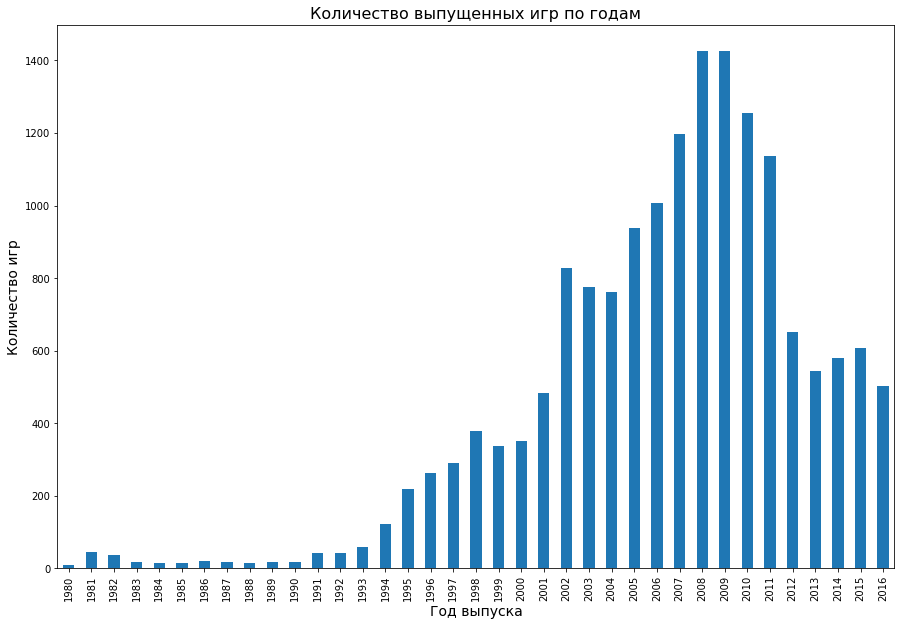

In [17]:
games.groupby('year_of_release')['name'].count().plot(kind='bar', x = 'year_of_release', figsize=(15,10))

# Добавление подписей
plt.title('Количество выпущенных игр по годам', fontsize=16)
plt.xlabel('Год выпуска', fontsize=14)
plt.ylabel('Количество игр', fontsize=14)

# Отображение графика
plt.show()

Как видно из графика, первые игры начали выпускаться еще в 1980 году. В последующие десятилетия количество выпущенных игр возрастало, достигнув пика в 2008-2009 годах, когда ежегодно выходило более 1400 игр. После этого заметен спад, который может быть обусловлен несколькими факторами, включая экономический кризис, оказавший негативное воздействие на индустрию. Также значительный вклад в изменение динамики могла внести растущая популярность смартфонов, более доступных в цене и обладающих большим функционалом по сравнению с игровыми платформами.

Изучим, как менялись продажи по платформам и проверим выводы, которые были описаны выше. 

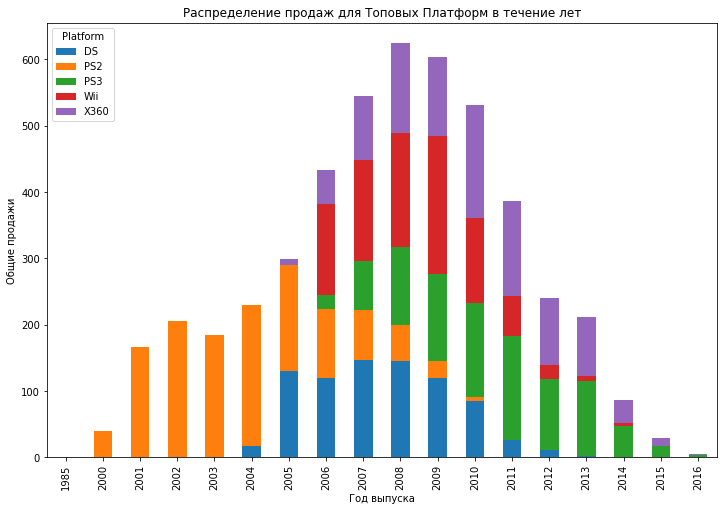

In [18]:
# Выбираем топ платформ с наибольшими суммарными продажами
top_platforms = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

# Создаем подвыборку для выбранных платформ
subset = games[games['platform'].isin(top_platforms)]

# Создаем сводную таблицу
pivot_table_platforms = subset.pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)

# Строим столбчатую диаграмму
pivot_table_platforms.plot(kind='bar', stacked=True, figsize=(12, 8))


# Добавляем заголовок и подписи к осям
plt.title('Распределение продаж для Топовых Платформ в течение лет')
plt.xlabel('Год выпуска')
plt.ylabel('Общие продажи')

# Включаем легенду
plt.legend(title='Platform', loc='upper left')

# Отображаем график
plt.show()

С начала 2000-х годов видеоигровая индустрия претерпела значительные изменения. В 2005 году Microsoft представила платформу Xbox X360, которая успешно удерживала лидерские позиции по продажам и играм в течение нескольких лет до 2015 года. Появление PS3 от Sony в 2006 году привело к постепенному снижению продаж игр для её предшественника, PS2. В период с 2006 по 2014 год наблюдалась заметная динамика смены поколений платформ - так в 2006 появились игры для платформ - DS, PS2, PS3, Wii, X360. Уже в 2011 году вышли из продаж игры PS2, а к 2016 год на рынке остались игры для платформ Xbox и PS3. 

Платформа Wii от Nintendo, появившись на рынке, заняла определённую нишу, но скоро потеряла свои позиции, что сказалось на снижении продаж игр для неё.

Анализ данных за период с 2000 по 2016 года позволяет наблюдать динамику изменений в индустрии видеоигр. Каждый год происходят сдвиги, влияющие на продажи игр. В контексте подготовки прогноза на 2017 год стоит обратить внимание на данные за последние годы (2014-2016), где заметно, что на рынке остались всего два крупных игрока - Playstation от Sony и Xbox от Microsoft.

In [37]:
# Комментарий ревьюера 2
temp = games.copy() 
time_life = temp.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 # в срок жизни платформы, должны входить границы диапазона, 
                                                            # поэтому +1
time_life['life'].median()

7.0

Возьмем данные за 2014-2016 года для дальнейшей работы и сохраним их в отдельную переменную.

In [19]:
# Отфильтровать данные за 2014-2016 годы
filtered_games = games[(games['year_of_release'] >= 2014) & (games['year_of_release'] <= 2016)]

# Сбросить индексы
filtered_games = filtered_games.reset_index(drop=True)

# Вывести информацию о новом датафрейме
filtered_games.info()

# Вывести первые строки нового датафрейма
filtered_games.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1689 entries, 0 to 1688
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1689 non-null   object 
 1   platform         1689 non-null   object 
 2   year_of_release  1689 non-null   Int64  
 3   genre            1689 non-null   object 
 4   na_sales         1689 non-null   float64
 5   eu_sales         1689 non-null   float64
 6   jp_sales         1689 non-null   float64
 7   other_sales      1689 non-null   float64
 8   critic_score     718 non-null    float64
 9   user_score       888 non-null    float64
 10  rating           940 non-null    object 
 11  total_sales      1689 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 160.1+ KB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
1,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
2,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,NaN,11.68
3,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
4,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98


Изучим подробнее, какие платформы лидируют по продажам, растут или падают в период с 2014 по 2016 года.

In [20]:
# Группируем данные по платформам и считаем суммарные продажи
platform_sales = filtered_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Выводим топ-10 платформ по суммарным продажам
top_platforms = platform_sales.head(10)
print(top_platforms)

platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
Name: total_sales, dtype: float64


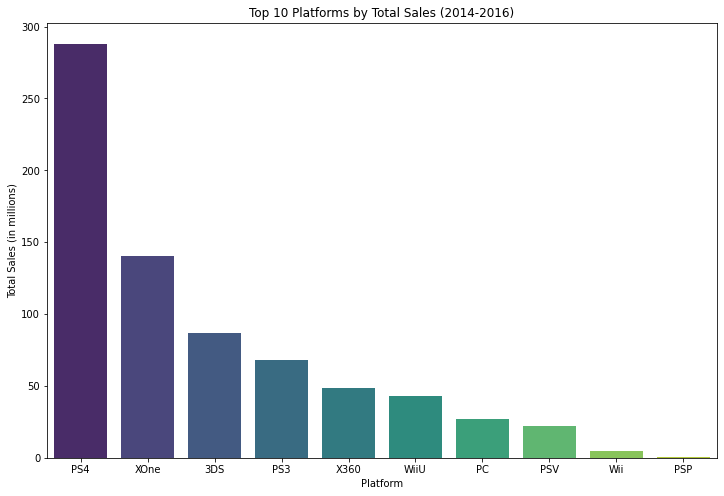

In [21]:
# Строим график для наглядности
plt.figure(figsize=(12, 8))
sns.barplot(x=top_platforms.index, y=top_platforms.values, palette='viridis')
plt.title('Top 10 Platforms by Total Sales (2014-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.show()

Как упоминалось ранее, в период с 2014 по 2016 годы на рынке игровых платформ выделялись два ключевых участника: Playstation от Sony и Xbox от Microsoft. График продаж подтверждает этот тренд. Более того, анализ предыдущих лет позволяет предположить, что пользователи, ранее игравшие на PS3, будут переходить на более современную платформу - PS4. Таким образом, в будущем году рекомендуется сосредоточить внимание на платформе PS4 и разрабатывать игры, соответствующие её техническим характеристикам.

Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам.

In [22]:
# выведим информацию по датафрейме для помощи
filtered_games.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
count,1689.000000,1689.000000,1689.000000,1689.000000,1689.000000,718.000000,888.000000,1689.000000
mean,2014.953227,0.168182,0.160261,0.055115,0.048324,72.306407,6.623536,0.431883
std,0.799624,0.446134,0.466846,0.211513,0.141790,12.213500,1.589792,1.056109
min,2014.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.200000,0.010000
25%,2014.000000,0.000000,0.000000,0.000000,0.000000,66.000000,5.800000,0.030000
50%,2015.000000,0.020000,0.020000,0.010000,0.010000,74.000000,7.000000,0.100000
75%,2016.000000,0.120000,0.120000,0.040000,0.040000,81.000000,7.800000,0.350000
max,2016.000000,6.030000,6.310000,3.180000,2.380000,97.000000,9.300000,14.630000


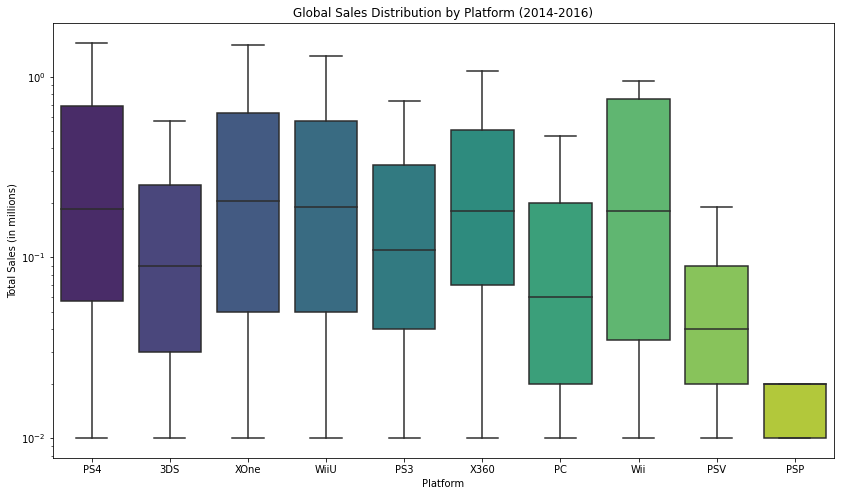

In [23]:
# Строим ящик с усами
plt.figure(figsize=(14, 8))
sns.boxplot(x='platform', y='total_sales', data=filtered_games, palette='viridis', showfliers=False)
plt.yscale('log')  # Устанавливаем логарифмическую шкалу по оси y


# Добавляем заголовок и подписи к осям
plt.title('Global Sales Distribution by Platform (2014-2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.show()



Из анализа графика "ящик с усами" по глобальным продажам игр в разбивке по платформам можно сделать следующие выводы:

PS4 и PS3: PS4 имеет более высокие медианные значения глобальных продаж по сравнению с PS3, что может указывать на более успешное внедрение и популярность новой платформы. Однако, PS3 имеет более компактное распределение, что может свидетельствовать о более стабильных продажах и меньшей вариабельности.

Xbox 360 и Xbox One: Обе платформы Xbox имеют схожую медиану глобальных продаж, но Xbox 360 имеет меньшее распределение, что может указывать на более стабильные продажи по сравнению с Xbox One. Различия в вариабельности могут быть связаны с временем существования платформ.

Продажи игр на платформе PSP в основном сконцентрированы на низких значениях, что говорит о непопулярности данной платформы.

Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построим диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами.

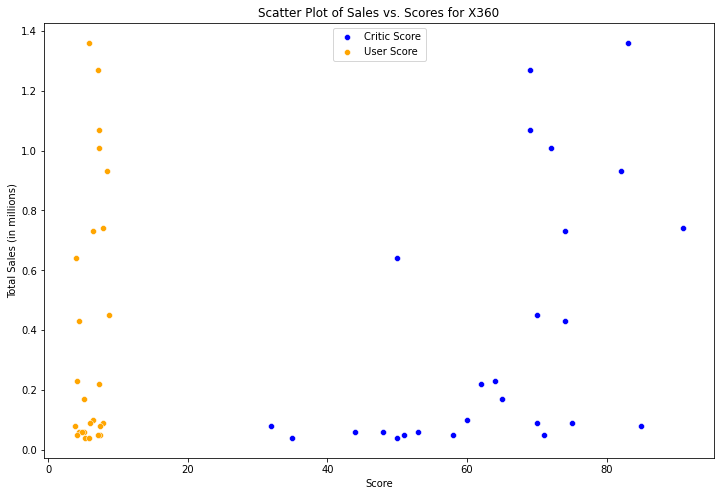

Корреляция между отзывами критиков и продажами: 0.53
Корреляция между отзывами пользователей и продажами: 0.34


In [24]:
# Выберите платформу, например, 'X360'
selected_platform = 'X360'

# Фильтрация данных для выбранной платформы и удаление пропущенных значений
platform_data = filtered_games[filtered_games['platform'] == selected_platform].dropna(subset=['critic_score', 'user_score', 'total_sales'])

# Построение диаграммы рассеяния
plt.figure(figsize=(12, 8))
sns.scatterplot(x='critic_score', y='total_sales', data=platform_data, label='Critic Score', color='blue')
sns.scatterplot(x='user_score', y='total_sales', data=platform_data, label='User Score', color='orange')

# Добавление заголовка и подписей к осям
plt.title(f'Scatter Plot of Sales vs. Scores for {selected_platform}')
plt.xlabel('Score')
plt.ylabel('Total Sales (in millions)')

# Включение легенды
plt.legend()

# Отображение графика
plt.show()

# Вычисление корреляции между отзывами и продажами
correlation_critic = platform_data['critic_score'].corr(platform_data['total_sales'])
correlation_user = platform_data['user_score'].corr(platform_data['total_sales'])

# Вывод результатов корреляции
print(f'Корреляция между отзывами критиков и продажами: {correlation_critic:.2f}')
print(f'Корреляция между отзывами пользователей и продажами: {correlation_user:.2f}')


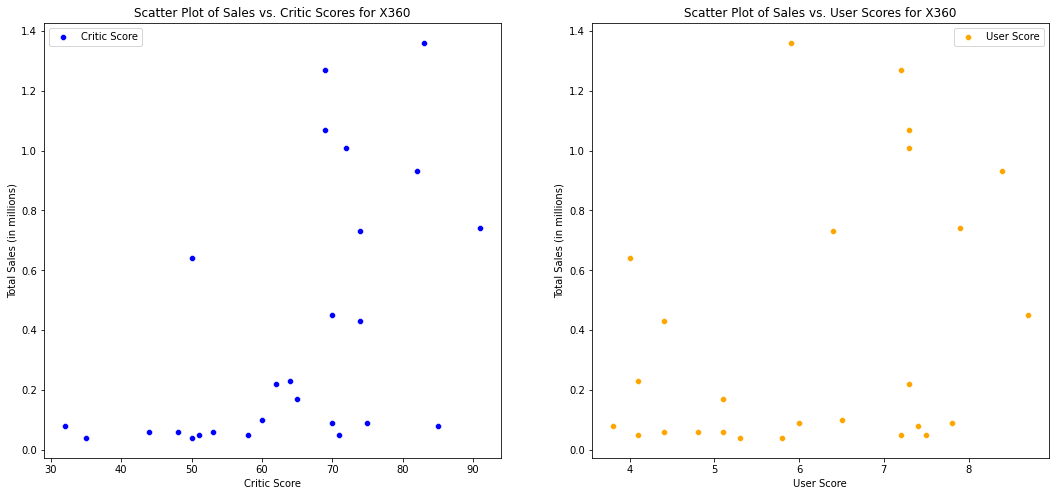

Корреляция между отзывами критиков и продажами: 0.53
Корреляция между отзывами пользователей и продажами: 0.34


In [25]:
# Выберите платформу, например, 'X360'
selected_platform = 'X360'

# Фильтрация данных для выбранной платформы и удаление пропущенных значений
platform_data = filtered_games[filtered_games['platform'] == selected_platform].dropna(subset=['critic_score', 'user_score', 'total_sales'])

# Построение диаграммы рассеяния
plt.figure(figsize=(18, 8))

# Диаграмма рассеяния для отзывов критиков
plt.subplot(1, 2, 1)
sns.scatterplot(x='critic_score', y='total_sales', data=platform_data, label='Critic Score', color='blue')
plt.title(f'Scatter Plot of Sales vs. Critic Scores for {selected_platform}')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (in millions)')
plt.legend()

# Диаграмма рассеяния для отзывов пользователей
plt.subplot(1, 2, 2)
sns.scatterplot(x='user_score', y='total_sales', data=platform_data, label='User Score', color='orange')
plt.title(f'Scatter Plot of Sales vs. User Scores for {selected_platform}')
plt.xlabel('User Score')
plt.ylabel('Total Sales (in millions)')
plt.legend()

# Отображение графиков
plt.show()

# Вычисление корреляции между отзывами и продажами
correlation_critic = platform_data['critic_score'].corr(platform_data['total_sales'])
correlation_user = platform_data['user_score'].corr(platform_data['total_sales'])

# Вывод результатов корреляции
print(f'Корреляция между отзывами критиков и продажами: {correlation_critic:.2f}')
print(f'Корреляция между отзывами пользователей и продажами: {correlation_user:.2f}')


Существует положительная корреляция между оценками критиков и общими продажами игр на данной платформе, что указывает на то, что чем выше оценка критиков, тем, вероятно, выше общий объем продаж. Корреляция между оценками пользователей и продажами также положительна, но она немного слабее по сравнению с оценками критиков. Таким образом, влияние оценок пользователей на продажи менее выражено, чем оценок критиков на данной платформе 'X360'.

Проверим корреляцию между рецензиями критиков и отзывами юзеров, используя цикл. Сохраним уникальные платформы в переменную platform, создадим два списка для хранения результатов. 

In [26]:
# Получите уникальные платформы в вашем датафрейме
platforms = filtered_games['platform'].unique()

# Создайте пустые списки для хранения результатов
correlation_critic_list = []
correlation_user_list = []

# Пройдите циклом по каждой платформе
for selected_platform in platforms:
    # Фильтрация данных для выбранной платформы и удаление пропущенных значений
    platform_data = filtered_games[filtered_games['platform'] == selected_platform].dropna(subset=['critic_score', 'user_score', 'total_sales'])
    
    # Вычисление корреляции между отзывами и продажами
    correlation_critic = platform_data['critic_score'].corr(platform_data['total_sales'])
    correlation_user = platform_data['user_score'].corr(platform_data['total_sales'])
    
    # Добавление результатов в списки
    correlation_critic_list.append(correlation_critic)
    correlation_user_list.append(correlation_user)

# Создайте DataFrame с результатами
results_df = pd.DataFrame({
    'Platform': platforms,
    'Correlation (Critic)': correlation_critic_list,
    'Correlation (User)': correlation_user_list
})

# Выведите таблицу с результатами
print(results_df)


  Platform  Correlation (Critic)  Correlation (User)
0      PS4              0.401903           -0.043186
1      3DS              0.284686            0.279850
2     XOne              0.422112           -0.091734
3     WiiU              0.375640            0.411451
4      PS3              0.446575            0.156595
5     X360              0.525723            0.336514
6       PC              0.172061           -0.089974
7      Wii                   NaN                 NaN
8      PSV              0.041029            0.023528
9      PSP                   NaN                 NaN


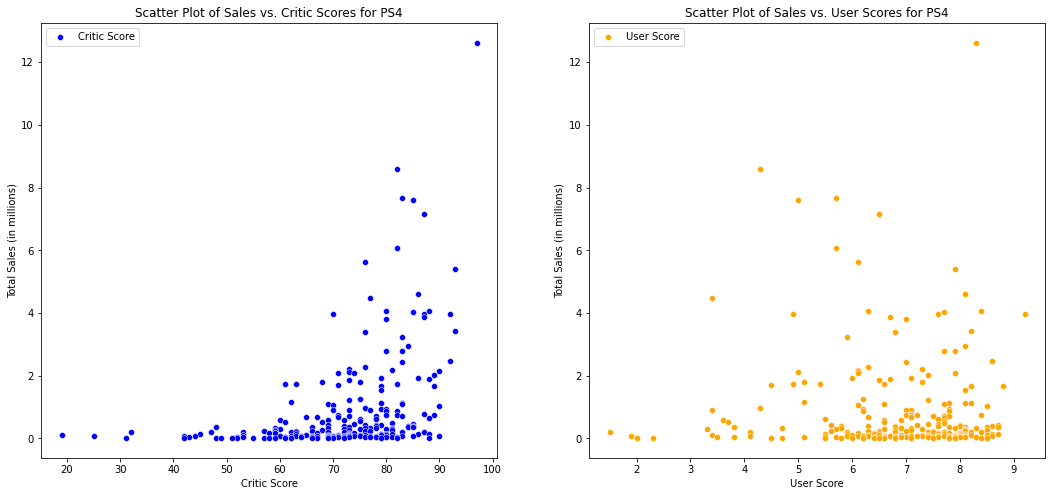

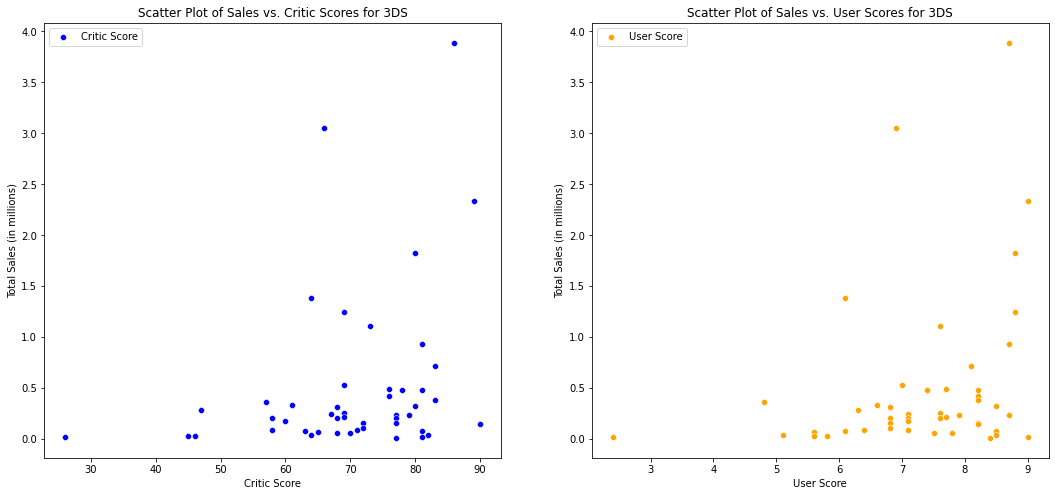

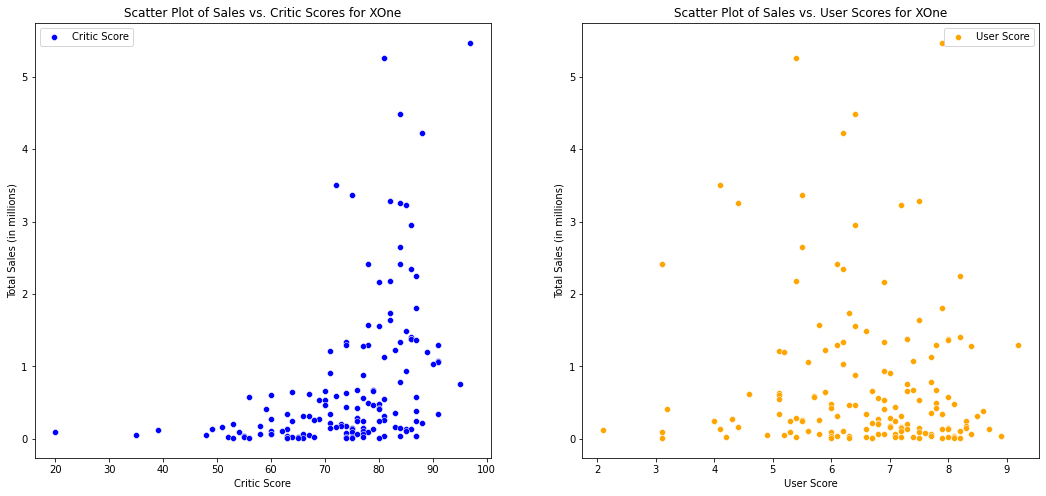

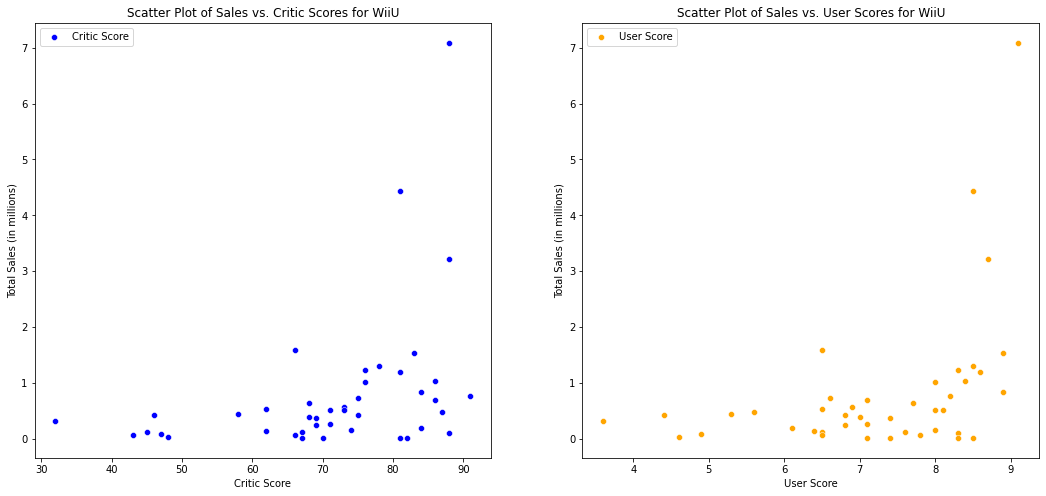

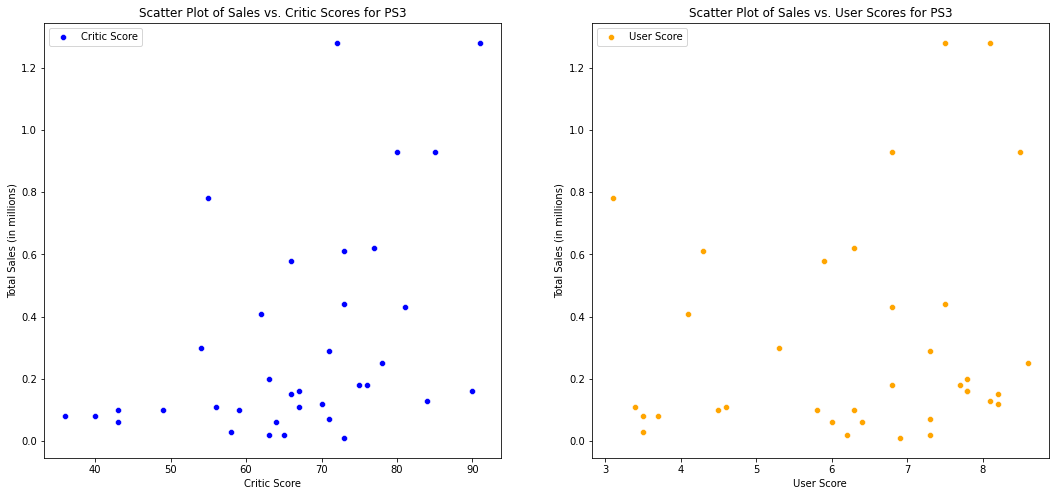

  Platform  Correlation (Critic)  Correlation (User)
0      PS4              0.401903           -0.043186
1      3DS              0.284686            0.279850
2     XOne              0.422112           -0.091734
3     WiiU              0.375640            0.411451
4      PS3              0.446575            0.156595


In [27]:
# Получите уникальные платформы в вашем датафрейме, исключая 'X360', 'Wii' и 'PSP'
platforms = filtered_games.loc[~filtered_games['platform'].isin(['X360', 'Wii', 'PSP']), 'platform'].unique()[:5]

# Создайте пустые списки для хранения результатов
correlation_critic_list = []
correlation_user_list = []

# Пройдите циклом по каждой платформе
for selected_platform in platforms:
    # Фильтрация данных для выбранной платформы и удаление пропущенных значений
    platform_data = filtered_games[filtered_games['platform'] == selected_platform].dropna(subset=['critic_score', 'user_score', 'total_sales'])
    
    # Построение диаграммы рассеяния
    plt.figure(figsize=(18, 8))

    # Диаграмма рассеяния для отзывов критиков
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='critic_score', y='total_sales', data=platform_data, label='Critic Score', color='blue')
    plt.title(f'Scatter Plot of Sales vs. Critic Scores for {selected_platform}')
    plt.xlabel('Critic Score')
    plt.ylabel('Total Sales (in millions)')
    plt.legend()

    # Диаграмма рассеяния для отзывов пользователей
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='user_score', y='total_sales', data=platform_data, label='User Score', color='orange')
    plt.title(f'Scatter Plot of Sales vs. User Scores for {selected_platform}')
    plt.xlabel('User Score')
    plt.ylabel('Total Sales (in millions)')
    plt.legend()

    # Отображение графиков
    plt.show()

    # Вычисление корреляции между отзывами и продажами
    correlation_critic = platform_data['critic_score'].corr(platform_data['total_sales'])
    correlation_user = platform_data['user_score'].corr(platform_data['total_sales'])
    
    # Добавление результатов в списки
    correlation_critic_list.append(correlation_critic)
    correlation_user_list.append(correlation_user)

# Создайте DataFrame с результатами
results_df = pd.DataFrame({
    'Platform': platforms,
    'Correlation (Critic)': correlation_critic_list,
    'Correlation (User)': correlation_user_list
})

# Выведите таблицу с результатами
print(results_df)



**Вывод:**
Судя по коэффициентам корреляции между отзывами критиков и продажами видеоигр на различных платформах, можно утверждать, что существует положительная корреляция между этими двумя переменными. Можно предположить, что юзеры приобретают игры, ориетируясь на рецензии критиков. Однако, коэффициенты корреляции между отзывами юзеров и продажами, наоборот, сигнализирует об отсутствии свзи между оценками пользователей и продажами 

Посмотрим на общее распределение игр по жанрам и продажи.


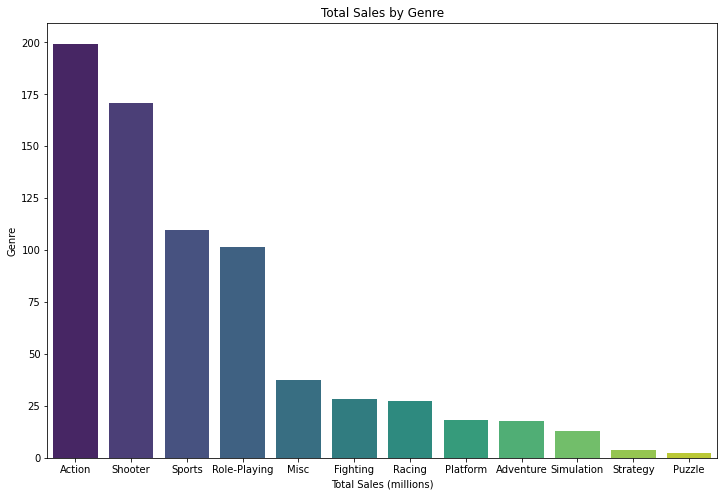

In [28]:
# Группируем данные по жанрам и суммируем продажи
genre_sales = filtered_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Строим график суммарных продаж по жанрам
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')

# Добавляем заголовок и подписи к осям
plt.title('Total Sales by Genre')
plt.xlabel('Total Sales (millions)')
plt.ylabel('Genre')

# Отображаем график
plt.show()


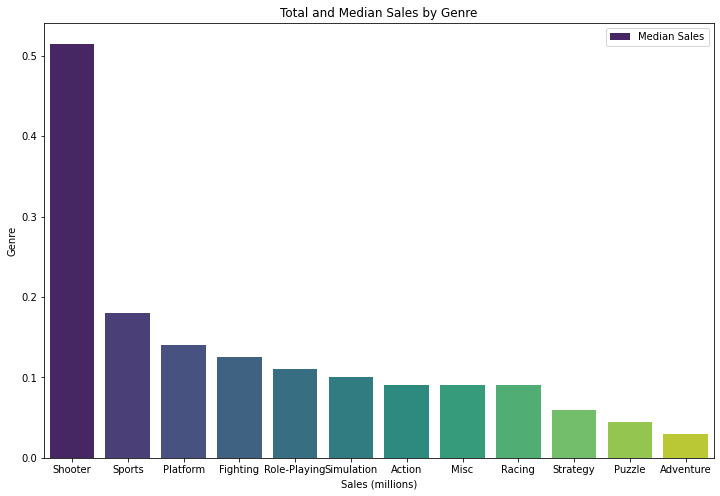

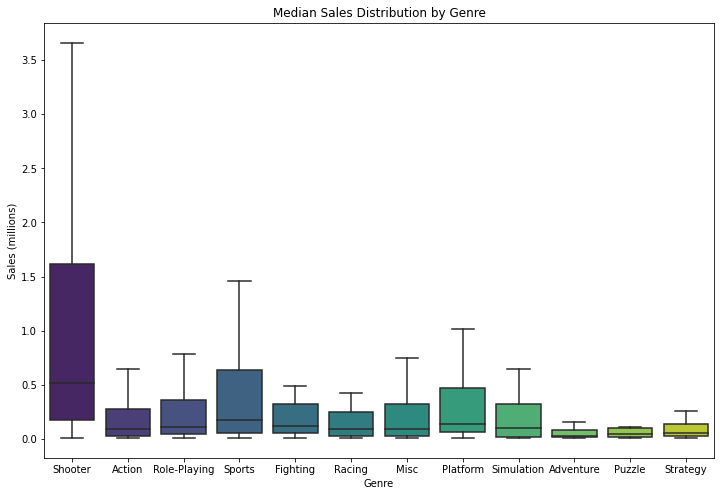

In [29]:


# Группируем данные по жанрам и вычисляем медианные продажи
genre_median_sales = filtered_games.groupby('genre')['total_sales'].median().sort_values(ascending=False)

# Строим график суммарных продаж по жанрам
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_median_sales.index, y=genre_median_sales.values, palette='viridis', label='Median Sales')

# Добавляем заголовок и подписи к осям
plt.title('Total and Median Sales by Genre')
plt.xlabel('Sales (millions)')
plt.ylabel('Genre')

# Добавляем легенду
plt.legend()

# Отображаем график
plt.show()

# Строим диаграмму размаха для медианных продаж
plt.figure(figsize=(12, 8))
sns.boxplot(x='genre', y='total_sales', data=filtered_games, palette='viridis', showfliers=False)

# Добавляем заголовок и подписи к осям
plt.title('Median Sales Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Sales (millions)')

# Отображаем график
plt.show()


**Вывод**: Суммарные продажи показывают, что игры в жанрах action, shooter и role-playing пользуются большей популярностью среди игроков, в то время как strategy и puzzle имеют более низкие общие продажи и, следовательно, меньший интерес. Однако, при анализе медианных продаж, мы видим, что лидирующими становятся shooter, sport и platform, что указывает на то, что эти жанры могут приносить более стабильные продажи на индивидуальном уровне.

# Шаг 4. Портрет пользователя каждого региона 

Рассмотрим, самые популярные платформы (топ-5)

<Figure size 864x576 with 0 Axes>

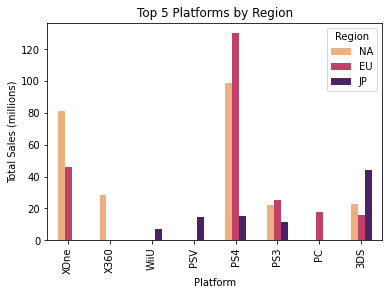

In [30]:
# Группируем данные по платформам и суммируем продажи для каждого региона
na_platform_sales = filtered_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platform_sales = filtered_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platform_sales = filtered_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

# Создаем датафрейм для удобства визуализации
platform_sales_df = pd.DataFrame({
    'NA': na_platform_sales,
    'EU': eu_platform_sales,
    'JP': jp_platform_sales
})
# Изменяем порядок строк в датафрейме
platform_sales_df = platform_sales_df.iloc[::-1]


# Строим график
plt.figure(figsize=(12, 8))
platform_sales_df.plot(kind='bar', colormap='flare')

# Добавляем заголовок и подписи к осям
plt.title('Top 5 Platforms by Region')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions)')

# Включаем легенду
plt.legend(title='Region', loc='upper right')

# Отображаем график
plt.show()


Предпочтения игровых платформ различаются в зависимости от региона. PS4 и XONe широко распространены в Северной Америке и Европе, в то время как в Японии популярны 3DS и PSV. Некоторые платформы, такие как PC, имеют переменную популярность в разных регионах.

Изучим, какие самые популярные жанры (топ-5). 

<Figure size 864x576 with 0 Axes>

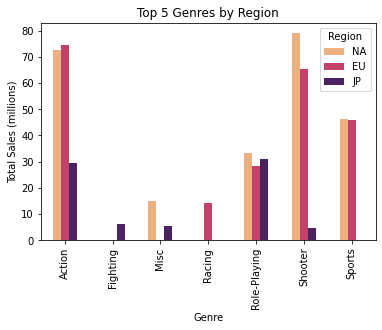

In [31]:
# Группируем данные по платформам и суммируем продажи для каждого региона
na_genre_sales = filtered_games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genre_sales = filtered_games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genre_sales = filtered_games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

# Создаем датафрейм для удобства визуализации
platform_genre_df = pd.DataFrame({
    'NA': na_genre_sales,
    'EU': eu_genre_sales,
    'JP': jp_genre_sales
})


# Строим график
plt.figure(figsize=(12, 8))
platform_genre_df.plot(kind='bar', colormap='flare')

# Добавляем заголовок и подписи к осям
plt.title('Top 5 Genres by Region')
plt.xlabel('Genre')
plt.ylabel('Total Sales (millions)')

# Включаем легенду
plt.legend(title='Region', loc='upper right')

# Отображаем график
plt.show()

Исследуя популярные жанры видеоигр в различных регионах, можно отметить, что в Северной Америке, Европе и Японии в топ-5 жанров входят шутеры (shooter), экшн (action), спортивные игры (sports), ролевые игры (role playing) и разнообразные игры (misc в Северной Америке и racing в Европе и Японии). Это говорит о схожих предпочтениях в популярных жанрах между различными регионами.

Изучим, влияет ли рейтинг ESRB на продажи в отдельном регионе

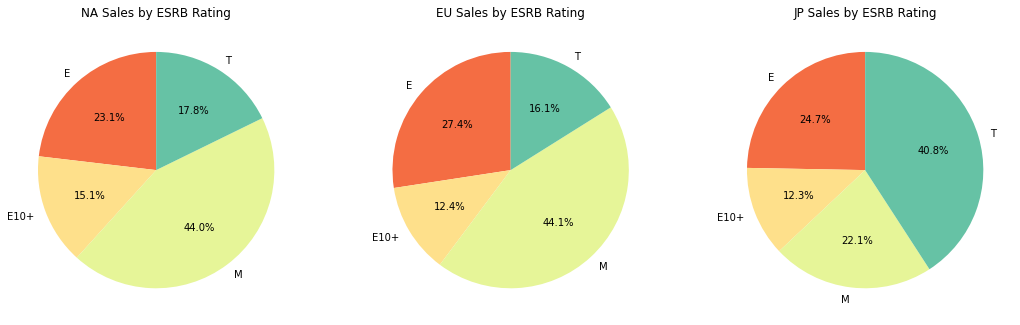

In [32]:
# Группируем данные по рейтингу ESRB и суммируем продажи для каждого региона
na_sales_by_rating = filtered_games.groupby('rating')['na_sales'].sum()
eu_sales_by_rating = filtered_games.groupby('rating')['eu_sales'].sum()
jp_sales_by_rating = filtered_games.groupby('rating')['jp_sales'].sum()

# Создаем датафрейм для удобства визуализации
sales_by_rating_df = pd.DataFrame({
    'NA': na_sales_by_rating,
    'EU': eu_sales_by_rating,
    'JP': jp_sales_by_rating
})
# Создаем свою цветовую палитру
colors = sns.color_palette('Spectral', len(sales_by_rating_df))

# Строим круговую диаграмму для каждого региона с использованием своей палитры
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Для региона NA
axes[0].pie(sales_by_rating_df['NA'], labels=sales_by_rating_df.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('NA Sales by ESRB Rating')

# Для региона EU
axes[1].pie(sales_by_rating_df['EU'], labels=sales_by_rating_df.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('EU Sales by ESRB Rating')

# Для региона JP
axes[2].pie(sales_by_rating_df['JP'], labels=sales_by_rating_df.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[2].set_title('JP Sales by ESRB Rating')

# Отображаем график
plt.show()


Для наглядности добавим столбчатую диаграмму.

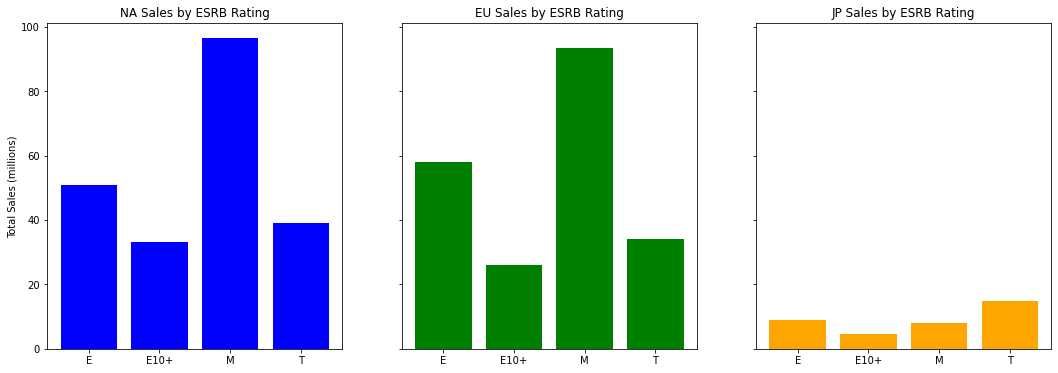

In [33]:
# Строим столбчатую диаграмму
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Для региона NA
axes[0].bar(sales_by_rating_df.index, sales_by_rating_df['NA'], color='blue')
axes[0].set_title('NA Sales by ESRB Rating')
axes[0].set_ylabel('Total Sales (millions)')

# Для региона EU
axes[1].bar(sales_by_rating_df.index, sales_by_rating_df['EU'], color='green')
axes[1].set_title('EU Sales by ESRB Rating')

# Для региона JP
axes[2].bar(sales_by_rating_df.index, sales_by_rating_df['JP'], color='orange')
axes[2].set_title('JP Sales by ESRB Rating')

# Отображаем график
plt.show()

**Вывод:** Влияние рейтинга ESRB на продажи видеоигр различается в зависимости от региона. В Северной Америке и Европе игры с рейтингом "Mature" продаются лучше, чем игры с рейтингом "Everyone". В Японии предпочтения более разнообразны, с продажами игр с рейтингами "Teen", "Everyone" и "Mature" на близком уровне. Тот факт, что в Японии достаточно высокий процент продаж с рейтингом "Teen" может говорить о популярности видео игры именно у детей подросткового возраста.

Вывод: Большой процент пропусков в столбце rating могут значительно повлиять на анализ, поскольку рейтинг ESRB может быть важным фактором для успешности игр в различных регионах. 

# Шаг 5. Проверка гипотез

Для сравнения средних пользовательских рейтингов платформ Xbox One и PC можно сформулировать следующие гипотезы:

Нулевая гипотеза (H0):
Средние пользовательские рейтинги платформ Xbox One и PC равны.

Альтернативная гипотеза (H1):
Средние пользовательские рейтинги платформ Xbox One и PC различаются.

In [35]:
xbox_one_ratings = filtered_games[(filtered_games['platform'] == 'XOne') & (filtered_games['user_score'].notnull())]['user_score']
pc_ratings = filtered_games[(filtered_games['platform'] == 'PC') & (filtered_games['user_score'].notnull())]['user_score']

alpha = 0.05
results = st.ttest_ind(xbox_one_ratings, pc_ratings, alternative='two-sided')
# Вывод значения p-значения
print('p-значение:', results.pvalue)

# Проверка условия и вывод результата
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 0.10450507919348415
Не получилось отвергнуть нулевую гипотезу


На основании предоставленных данных, у нас нет достаточных статистических оснований для утверждения, что средние пользовательские рейтинги платформ Xbox One и PC различаются. Поэтому мы можем предполагать, что средние пользовательские рейтинги этих двух платформ одинаковы.

**Для сравнения средних пользовательских рейтингов жанров Action и Sports можно сформулировать следующие гипотезы:**



Нулевая гипотеза (H0):
Средние пользовательские рейтинги жанров Action и Sports одинаковы.

Альтернативная гипотеза (H1):
Средние пользовательские рейтинги жанров Action и Sports различаются.

В данном исследовании мы проводим сравнение средних пользовательских рейтингов для жанров Action и Sports с помощью t-теста. Нулевая гипотеза предполагает, что средние рейтинги обоих жанров одинаковы, в то время как альтернативная гипотеза предполагает наличие различий между этими рейтингами. Для проверки этих гипотез мы применяем t-тест, основываясь на предположении о нормальном распределении пользовательских рейтингов и независимости выборок.

In [36]:
action_ratings = filtered_games[(filtered_games['genre'] == 'Action') & (filtered_games['user_score'].notnull())]['user_score']
sports_ratings = filtered_games[(filtered_games['genre'] == 'Sports') & (filtered_games['user_score'].notnull())]['user_score']

alpha = 0.05
results_genre = st.ttest_ind(action_ratings, sports_ratings, alternative='two-sided')

# Вывод значения p-значения
print('p-значение:', results_genre.pvalue)

# Проверка условия и вывод результата
if results_genre.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

# Расчет средних пользовательских рейтингов
print(action_ratings.mean())
print(sports_ratings.mean())


p-значение: 2.8711147985105864e-19
Отвергаем нулевую гипотезу
6.760606060606061
5.2251968503937


Исходя из полученного очень низкого p-значения (меньше уровня значимости 0.05), у нас есть статистически значимые доказательства для отвержения нулевой гипотезы. Таким образом, мы можем сделать вывод, что средние пользовательские рейтинги жанров Action и Sports различаются. С учетом средних значений, можно сказать, что игры в жанре Action в среднем получают более высокие пользовательские рейтинги по сравнению с играми в жанре Sports.

# Шаг 6. Общий вывод

Общий вывод

Мы тщательно исследовали данные о видеоиграх, начиная с их описания и обработки проблем - пропускоа и дубликатов - в данных. После этого мы изучили динамику выпуска игр по годам и выявили периоды роста и спада в индустрии. Важно отметить, что пиковые значения приходились на конец 2000-х годов, однако для анализа мы оставновились на периоде 2014-2016 гг., более подходящим под цели нашего исследования. 

Мы также проанализировали платформы и выявили, что PS4 и Xbox One являются перспективными. Рекомендуется обратить внимание именно на игры для этих платформ при закупках. 

По жанрам выяснилось, что на первый взгляд популярные action и role-playing игры, на самом деле деле, уступают играм в жанре **shooter** и **sport**, эти в свою очередь показывают более стабильные продажи. 

Изучив предпочтения по регионам, мы обнаружили различия в популярности платформ и жанров в Северной Америке, Европе и Японии, а потому можем дать следующие рекомендации:
- в Северной Америке и Европе стоит сконцентрироваться на играх в жанре **Action** и **Shooter** для платформ **PS4** и **XOne**;
- для Японии лучше выбрать игры в жанрах **Role-Playing** и **Action** на платформах **3DS** и **PSV**.

Важно отметить, что рейтинг ESRB применим в основном для Америки и Канады, а значит нужно делать больший упор на игры с рейтингом M и E.

Оценки критиков имеют важное значение и напрямую связаны с успешностью продаж, а потом следует уделить время и ресурсы на разработку маркетинговые кампании совместно с критиками/экспертами индустрии